# Introducción a CLASS-ulSFDM

## Primeros pasos con CLASS y `classy`

En este notebook aprenderemos a utilizar el módulo de Python classy, la interfaz de CLASS para Python. Como primer ejemplo utilizaremos el modelo cosmológico estándar ΛCDM para verificar que la instalación funciona correctamente y familiarizarnos con el flujo de trabajo antes de estudiar el modelo de Materia Oscura Escalar Ultraligera (ulSFDM).

## Importar librerías 

In [4]:
# Mostrar las figuras dentro del notebook
%matplotlib inline
# Utilizar formato SVG para obtener figuras nítidas
%config InlineBackend.figure_format = "svg"

# ------------------------------------------------------------
# Librerías 
# ------------------------------------------------------------
import sys
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Importar CLASS / classy
# ------------------------------------------------------------
# Importar la interfaz de Python de CLASS
import classy
from classy import Class

print("classy importado correctamente.")
print(f"Python utilizado: {sys.executable}")
print(f"Módulo importado desde: {classy.__file__}")

classy importado correctamente.
Python utilizado: /Users/johnatanroman/anaconda3/envs/bobe/bin/python
Módulo importado desde: /Users/johnatanroman/anaconda3/envs/bobe/lib/python3.11/site-packages/classy/__init__.py


> **Verificación del entorno**
>
> La ruta mostrada para el intérprete de Python y para el módulo `classy`
> debe coincidir con la obtenida durante el **Paso 7: Verificar la instalación**
> del README. Si ambas rutas coinciden, significa que Jupyter está utilizando
> el mismo ambiente de Conda y la misma instalación de CLASS-ulSFDM que se
> verificó previamente desde la terminal.

# Modelo cosmológico: ΛCDM
Configuraremos un modelo cosmológico ΛCDM utilizando los parámetros de la colaboración Planck 2018.
Una vez definidos los parámetros, compute() resolverá numéricamente la evolución del fondo cosmológico y de las perturbaciones lineales.

In [5]:
cosmo = {}
st_time= time.time()
LCDM='LCDM'
cosmo[LCDM] = Class()
cosmo[LCDM].set({'A_s':2.100549e-09,
                 'n_s':0.9660499,
                 'h': 0.67810,
                 'Omega_sfdm':0.,'omega_cdm':0.1201075, 'omega_b':0.02238280,
                 'T_cmb':2.7255,'z_reio':7.6711,'output':'tCl, lCl, mPk',
                 'N_ur': 2.0308, 'N_ncdm': 1, 'm_ncdm': 0.06,
                 'P_k_max_1/Mpc':100.,'z_pk':'0.','lensing':'yes','format':'camb'})
cosmo[LCDM].compute()
print(f"Tiempo: {time.time()-st_time:.2f} s")

Tiempo: 2.19 s


Aunque en este ejemplo utilizamos el modelo ΛCDM, estamos ejecutando la versión modificada de CLASS desarrollada para este taller. Por ello, el parámetro Omega_sfdm se fija en cero, desactivando la contribución de la materia oscura escalar ultraligera y recuperando el caso estándar de ΛCDM.

## Consultar parámetros cosmológicos

Una vez finalizado el cálculo, `classy` permite acceder a numerosos parámetros cosmológicos derivados mediante distintos métodos de la clase `Class`.

En este ejemplo consultaremos algunos de los parámetros más utilizados:

- **\(h\)**: constante de Hubble reducida.
- **\(\Omega_m\)**: densidad fraccional actual de materia total.
- **\(\Omega_Lambda\)**: densidad fraccional actual de constante cosmológica.
- **\(\sigma_8\)**: amplitud de las fluctuaciones lineales de la densidad de materia  $(8\,h^{-1}\,\mathrm{Mpc})$.
- **Edad del Universo**: tiempo transcurrido desde el Big Bang hasta la actualidad.

In [6]:
# ------------------------------------------------------------
# Parámetros cosmológicos derivados
# ------------------------------------------------------------

print(f"h        = {cosmo[LCDM].h():.6f}")
print(f"Omega_m  = {cosmo[LCDM].Omega_m():.6f}")
print(f"Omega_Λ  = {cosmo[LCDM].Omega_Lambda():.6f}")
print(f"sigma8   = {cosmo[LCDM].sigma8():.6f}")
print(f"Age      = {cosmo[LCDM].age():.6f} Gyr")

h        = 0.678100
Omega_m  = 0.311284
Omega_Λ  = 0.688637
sigma8   = 0.813085
Age      = 13.753818 Gyr


## Explorar las cantidades del fondo cosmológico

El método `get_background()` devuelve un diccionario de Python que contiene la evolución temporal de numerosas cantidades del fondo cosmológico calculadas por CLASS.

Podemos inspeccionar las variables disponibles mediante el método `keys()`.

In [7]:
# Mostrar las variables disponibles del fondo cosmológico
print(cosmo[LCDM].get_background().keys())

dict_keys(['z', 'proper time [Gyr]', 'conf. time [Mpc]', 'H [1/Mpc]', 'comov. dist.', 'ang.diam.dist.', 'lum. dist.', 'comov.snd.hrz.', '(.)rho_g', '(.)rho_b', '(.)rho_cdm', '(.)rho_ncdm[0]', '(.)p_ncdm[0]', '(.)rho_lambda', '(.)rho_ur', '(.)rho_crit', '(.)rho_tot', '(.)p_tot', '(.)p_tot_prime', 'Omega_r(z)', 'Omega_m(z)', 'gr.fac. D', 'gr.fac. f'])


## Evolución del fondo cosmológico

El método `get_background()` devuelve un diccionario con la evolución del fondo cosmológico. A continuación extraeremos algunas de sus variables más importantes para construir las primeras gráficas del modelo ΛCDM.

In [8]:
# ------------------------------------------------------------
# Evolución del fondo cosmológico
# ------------------------------------------------------------

# Obtener las cantidades del fondo calculadas por CLASS
bg = cosmo[LCDM].get_background()

# ------------------------------------------------------------
# Variables independientes
# ------------------------------------------------------------
z = bg["z"] # Corrimiento al rojo
a = 1.0 / (1.0 + z) # Factor de escala
loga = np.log10(a) # Logaritmo decimal del factor de escala

# Densidad crítica
rho_crit = bg["(.)rho_crit"]

# ------------------------------------------------------------
# Densidades de energía
# ------------------------------------------------------------

# Radiación
rho_g  = bg["(.)rho_g"]          # Fotones
rho_ur = bg["(.)rho_ur"]         # Neutrinos relativistas
rho_r  = rho_g + rho_ur          #Densidad de radiación, incluye fotones y neutrinos relativistas

# Materia
rho_b    = bg["(.)rho_b"]        # Bariones
rho_cdm  = bg["(.)rho_cdm"]      # Materia oscura fría
rho_ncdm = bg["(.)rho_ncdm[0]"]  # Neutrinos masivos

# Energía oscura
rho_lambda = bg["(.)rho_lambda"]

# ------------------------------------------------------------
# Parámetros de densidad Omega
# ------------------------------------------------------------

Omega_g      = rho_g      / rho_crit
Omega_ur     = rho_ur     / rho_crit
Omega_r      = rho_r      / rho_crit
Omega_b      = rho_b      / rho_crit
Omega_cdm    = rho_cdm    / rho_crit
Omega_ncdm   = rho_ncdm   / rho_crit
Omega_lambda = rho_lambda / rho_crit

# ------------------------------------------------------------
# Presiones p=w*\rho
# ------------------------------------------------------------
p_r       = rho_r / 3.0
p_b       = 0*rho_b
p_cdm     = 0*rho_cdm
p_lambda  = -rho_lambda
p_ncdm    = bg["(.)p_ncdm[0]"]

# ------------------------------------------------------------
# Colores para las gráficas
# ------------------------------------------------------------

colors = {
    "rad": "red",
    "nu": "orange",
    "b": "tab:blue",
    "cdm": "black",
    "lambda": "tab:cyan",
}

A partir de las cantidades obtenidas con `get_background()`, podemos estudiar la evolución de las distintas componentes del Universo. En las siguientes gráficas se muestran:

- La densidad de energía de cada componente.
- Los parámetros de densidad $\Omega_i$.
- La ecuación de estado $\omega=p/\rho$.

Estas cantidades permiten identificar las diferentes épocas de dominancia del Universo, como la radiación, la materia y la energía oscura.

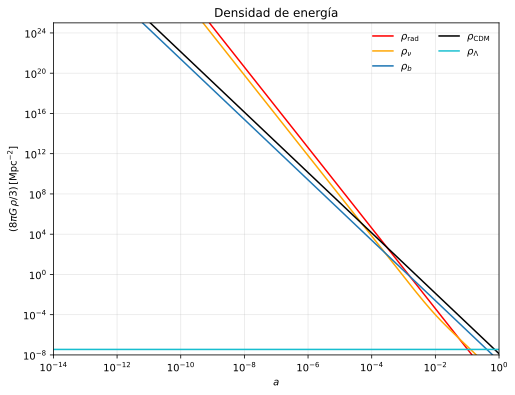

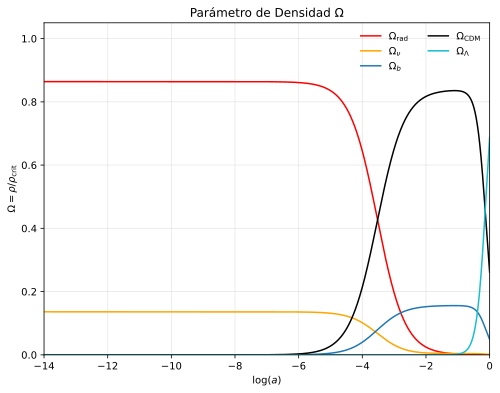

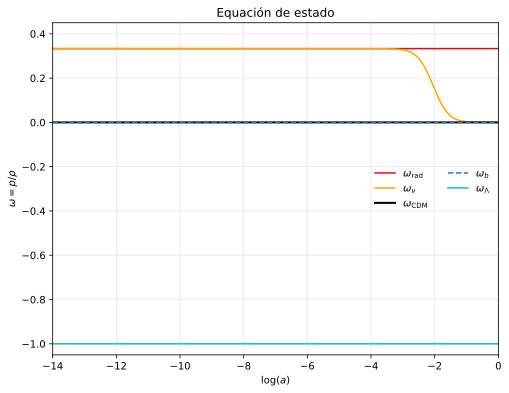

In [9]:
# Plot: Energy densities
fig, ax = plt.subplots(figsize=(8, 6))

ax.loglog(a, rho_r,      color=colors["rad"],  label=r'$\rho_{\rm rad}$')
ax.loglog(a, rho_ncdm,   color=colors["nu"],     label=r'$\rho_\nu$')
ax.loglog(a, rho_b,      color=colors["b"],      label=r'$\rho_b$')
ax.loglog(a, rho_cdm,    color=colors["cdm"],    label=r'$\rho_{\rm CDM}$')
ax.loglog(a, rho_lambda, color=colors["lambda"], label=r'$\rho_\Lambda$')

ax.set_xlim(1e-14, 1)
ax.set_ylim(1e-8, 1e25)

ax.set_xlabel(r'$a$')
ax.set_ylabel(r'$(8\pi G\,\rho/3)\,[{\rm Mpc}^{-2}]$')

ax.set_title(r'Densidad de energía')
ax.grid(True, which='both', alpha=0.3)
ax.legend(frameon=False, ncol=2)

plt.show()

#-------------------------------
# Plot: Density Parameters Omega
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(loga, Omega_r,     color=colors["rad"],      label=r'$\Omega_{\rm rad}$')
ax.plot(loga, Omega_ncdm,   color=colors["nu"], label=r'$\Omega_\nu$')
ax.plot(loga, Omega_b,      color=colors["b"],      label=r'$\Omega_b$')
ax.plot(loga, Omega_cdm,    color=colors["cdm"],      label=r'$\Omega_{\rm CDM}$')
ax.plot(loga, Omega_lambda, color=colors["lambda"],      label=r'$\Omega_\Lambda$')

ax.set_xlim(-14, 0)
ax.set_ylim(0, 1.05)

ax.set_xlabel(r'$\log(a)$')
ax.set_ylabel(r'$\Omega=\rho/\rho_{\rm crit}$')

ax.grid(alpha=0.3)
ax.legend(frameon=False, ncol=2)
ax.set_title(r"Parámetro de Densidad $\Omega$")

plt.show()

# ------------------------------------------------------------
# Plot: Equations of state
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot( loga, p_r/rho_r, color=colors["rad"],linestyle='-', label=r'$\omega_{\rm rad}$')
ax.plot( loga, p_ncdm/rho_ncdm, color=colors["nu"], label=r'$\omega_\nu$')
ax.plot( loga, p_cdm/rho_cdm, color=colors["cdm"], lw='2', label=r'$\omega_{\rm CDM}$')
ax.plot( loga, p_b/rho_b,  color=colors["b"], ls='--', label=r'$\omega_b$')
ax.plot( loga, p_lambda/rho_lambda, color=colors["lambda"], label=r'$\omega_\Lambda$')

ax.set_xlim(-14, 0)
ax.set_ylim(-1.05, 0.45)

ax.set_xlabel(r'$\log(a)$')
ax.set_ylabel(r'$\omega=p/\rho$')

ax.set_title('Equación de estado')
ax.grid(alpha=0.3)
ax.legend(frameon=False, ncol=2)

plt.show()